# Comparison: Bayesian Optimization vs Random Search

Each method was run 5 times (seeds 0–4) with 50 iterations per run.
This notebook compares convergence speed, final performance, and sampling behavior.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

bo = pd.read_csv("../reports/results_bayesian.csv")
rand = pd.read_csv("../reports/results_random.csv")

bo["method"] = "Bayesian Optimization"
rand["method"] = "Random Search"

df = pd.concat([bo, rand], ignore_index=True)

COLORS = {
    "Bayesian Optimization": "#d62728",
    "Random Search": "#1f77b4",
}
methods_ordered = ["Bayesian Optimization", "Random Search"]
bar_colors = [COLORS[m] for m in methods_ordered]

print(f"Total rows: {len(df)}")
print(f"Methods: {df['method'].unique().tolist()}")
print(f"Seeds per method: {df.groupby('method')['seed'].nunique().to_dict()}")
print(f"Iterations per seed: {df.groupby(['method','seed'])['iteration'].count().unique().tolist()}")

Total rows: 500
Methods: ['Bayesian Optimization', 'Random Search']
Seeds per method: {'Bayesian Optimization': 5, 'Random Search': 5}
Iterations per seed: [50]


---
## 1. Summary Table: Final Best Temperature per Method

In [15]:
final = (
    df.groupby(["method", "seed"])["best_temp"]
    .last()
    .reset_index()
    .rename(columns={"best_temp": "final_best_temp"})
)

summary = (
    final.groupby("method")["final_best_temp"]
    .agg(["mean", "std", "min", "max", "median"])
    .round(2)
    .sort_values("mean", ascending=False)
    .reset_index()
)
summary.columns = ["Method", "Mean (°C)", "Std (°C)", "Min (°C)", "Max (°C)", "Median (°C)"]
summary.style.background_gradient(subset=["Mean (°C)"], cmap="YlOrRd")

,Method,Mean (°C),Std (°C),Min (°C),Max (°C),Median (°C)
0,Bayesian Optimization,34.560000,2.190000,31.700000,37.700000,34.900000
1,Random Search,30.400000,3.050000,28.300000,35.700000,29.800000


## 2. Final Best Temperature per Seed (Detailed)

In [33]:
seed_table = final.pivot(index="seed", columns="method", values="final_best_temp")
seed_table = seed_table[["Bayesian Optimization", "Random Search"]]
seed_table.loc["Mean"] = seed_table.mean()
seed_table.loc["Std"] = seed_table.iloc[:-1].std()
seed_table = seed_table.round(2)
seed_table.style.background_gradient(axis=None, cmap="YlOrRd", subset=pd.IndexSlice[seed_table.index[:-2], :])

method,Bayesian Optimization,Random Search
seed,,
0,34.900000,29.800000
1,34.900000,28.400000
2,33.600000,29.800000
3,31.700000,28.300000
4,37.700000,35.700000
Mean,34.560000,30.400000
Std,2.190000,3.050000


---
## 3. Convergence Curves: Best Temperature Over Iterations

Shows how quickly each method finds high temperatures. Solid line = mean across 5 seeds, shaded area = min–max range.

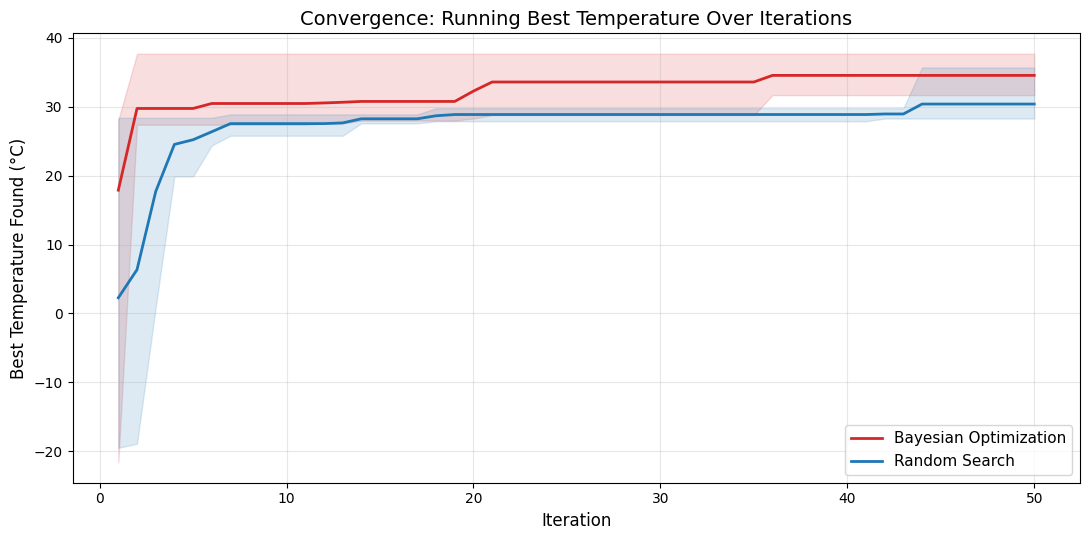

In [17]:
fig, ax = plt.subplots(figsize=(11, 5.5))

for method, color in COLORS.items():
    sub = df[df["method"] == method]
    pivot = sub.pivot(index="iteration", columns="seed", values="best_temp")
    mean = pivot.mean(axis=1)
    lo = pivot.min(axis=1)
    hi = pivot.max(axis=1)
    ax.plot(mean.index, mean.values, label=method, color=color, linewidth=2)
    ax.fill_between(mean.index, lo.values, hi.values, color=color, alpha=0.15)

ax.set_xlabel("Iteration", fontsize=12)
ax.set_ylabel("Best Temperature Found (°C)", fontsize=12)
ax.set_title("Convergence: Running Best Temperature Over Iterations", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/convergence_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Convergence per Seed (Individual Runs)

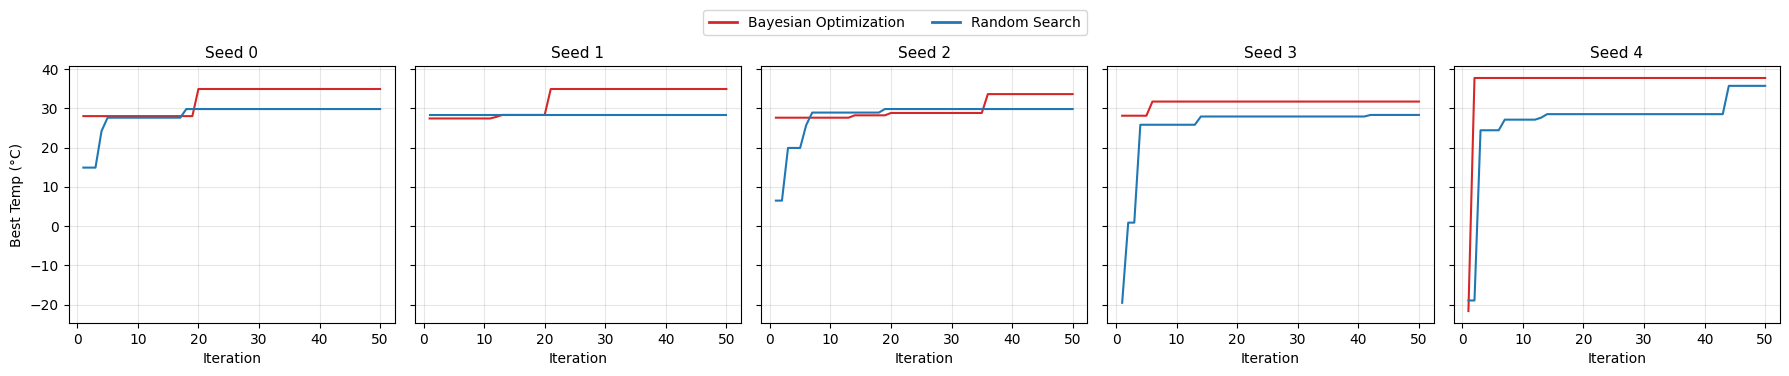

In [18]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), sharey=True)

for i, seed in enumerate(range(5)):
    ax = axes[i]
    for method, color in COLORS.items():
        sub = df[(df["method"] == method) & (df["seed"] == seed)]
        ax.plot(sub["iteration"], sub["best_temp"], color=color, linewidth=1.5, label=method)
    ax.set_title(f"Seed {seed}", fontsize=11)
    ax.set_xlabel("Iteration")
    if i == 0:
        ax.set_ylabel("Best Temp (°C)")
    ax.grid(True, alpha=0.3)

handles = [Line2D([0], [0], color=c, linewidth=2, label=m) for m, c in COLORS.items()]
fig.legend(handles=handles, loc="upper center", ncol=2, fontsize=10, bbox_to_anchor=(0.5, 1.08))
plt.tight_layout()
plt.savefig("../reports/figures/convergence_per_seed.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5. Bar Chart: Mean Final Temperature with Error Bars

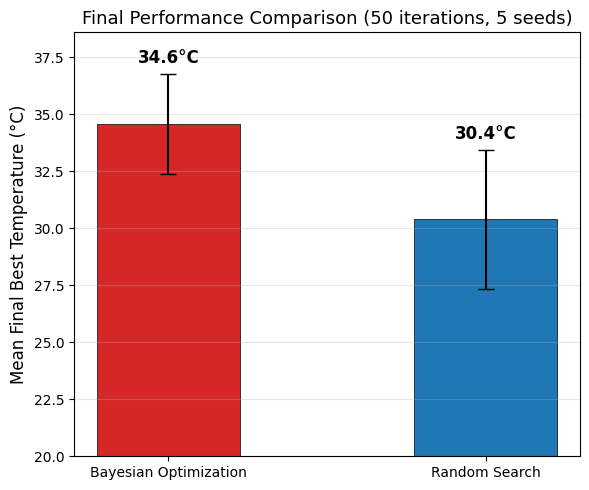

In [19]:
means = [final[final["method"] == m]["final_best_temp"].mean() for m in methods_ordered]
stds = [final[final["method"] == m]["final_best_temp"].std() for m in methods_ordered]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(methods_ordered, means, yerr=stds, capsize=6,
              color=bar_colors, edgecolor="black", linewidth=0.5, width=0.45)

for bar, val, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + std + 0.3,
            f"{val:.1f}°C", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_ylabel("Mean Final Best Temperature (°C)", fontsize=12)
ax.set_title("Final Performance Comparison (50 iterations, 5 seeds)", fontsize=13)
ax.set_ylim(bottom=20)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/bar_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Box Plot: Distribution of Final Best Temperatures

/var/folders/tc/kcvxq0px1svf293wbm1j742w0000gn/T/ipykernel_88876/3566187188.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=methods_ordered, patch_artist=True, widths=0.4)


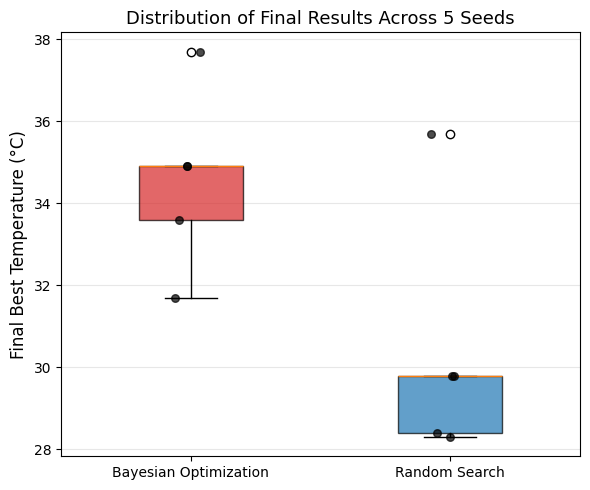

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))

data_box = [final[final["method"] == m]["final_best_temp"].values for m in methods_ordered]
bp = ax.boxplot(data_box, labels=methods_ordered, patch_artist=True, widths=0.4)

for patch, color in zip(bp["boxes"], bar_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i, m in enumerate(methods_ordered):
    vals = final[final["method"] == m]["final_best_temp"].values
    x = np.random.normal(i + 1, 0.04, size=len(vals))
    ax.scatter(x, vals, color="black", s=30, zorder=5, alpha=0.7)

ax.set_ylabel("Final Best Temperature (°C)", fontsize=12)
ax.set_title("Distribution of Final Results Across 5 Seeds", fontsize=13)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/box_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Sampling Locations on World Map

Shows where each method chose to sample. BO should cluster in hot regions, Random should be spread everywhere.

/var/folders/tc/kcvxq0px1svf293wbm1j742w0000gn/T/ipykernel_88876/2560682435.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


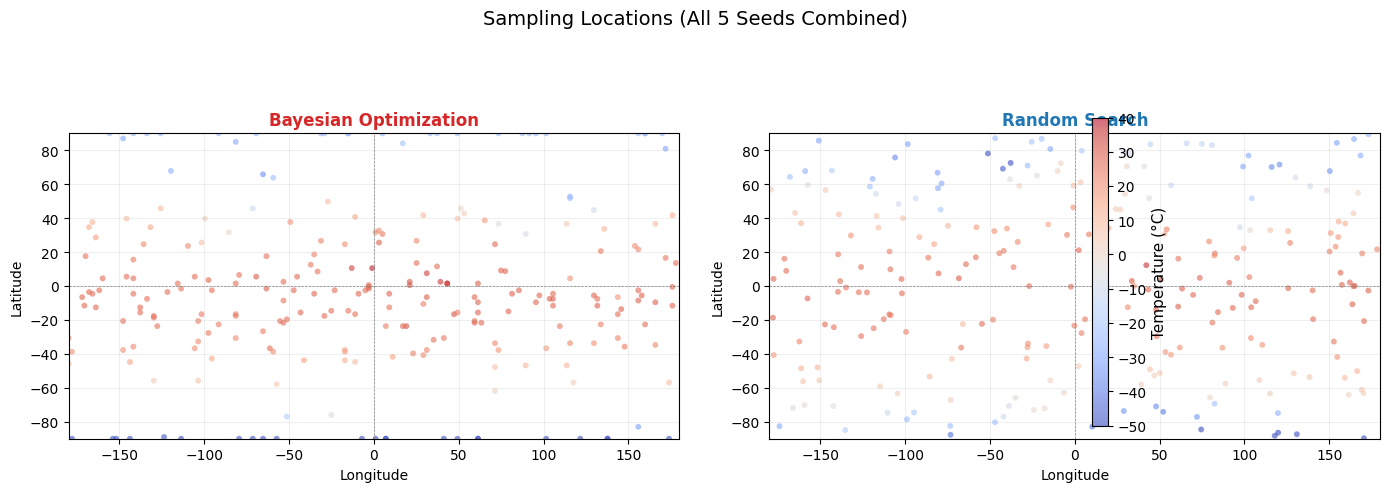

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (method, color) in zip(axes, COLORS.items()):
    sub = df[df["method"] == method]
    scatter = ax.scatter(sub["lng"], sub["lat"], c=sub["temp"], cmap="coolwarm",
                         s=18, alpha=0.6, edgecolors="none", vmin=-50, vmax=40)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    ax.set_title(method, fontsize=12, color=color, fontweight="bold")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.2)

cbar = fig.colorbar(scatter, ax=axes, shrink=0.8, pad=0.02)
cbar.set_label("Temperature (°C)", fontsize=11)
plt.suptitle("Sampling Locations (All 5 Seeds Combined)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../reports/figures/sampling_locations.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Temperature Distribution of Sampled Points

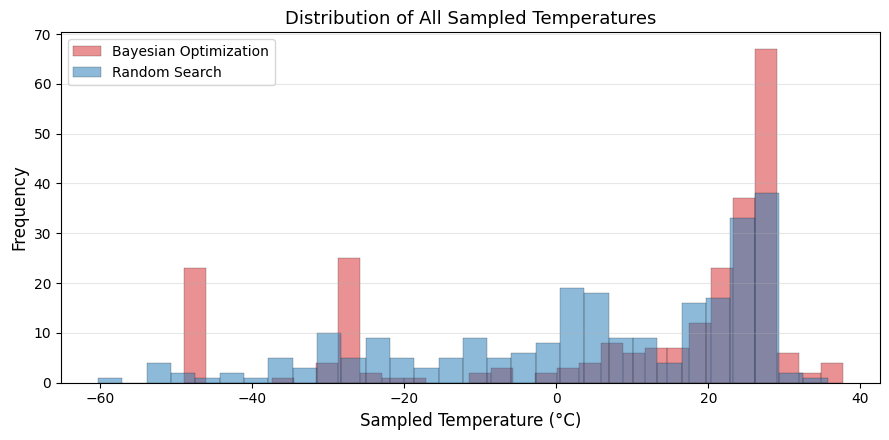

In [22]:
fig, ax = plt.subplots(figsize=(9, 4.5))

for method, color in COLORS.items():
    temps = df[df["method"] == method]["temp"]
    ax.hist(temps, bins=30, alpha=0.5, color=color, label=method, edgecolor="black", linewidth=0.3)

ax.set_xlabel("Sampled Temperature (°C)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title("Distribution of All Sampled Temperatures", fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/temp_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Efficiency: Iteration Where Best Temperature Was First Found

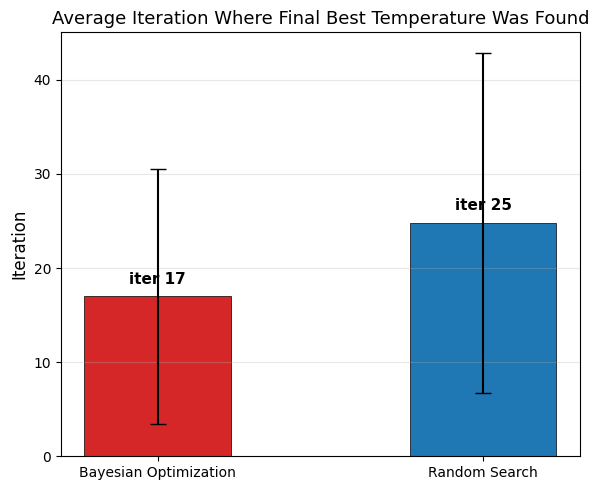

In [23]:
best_found_at = []
for method in methods_ordered:
    for seed in range(5):
        sub = df[(df["method"] == method) & (df["seed"] == seed)].copy()
        final_best = sub["best_temp"].iloc[-1]
        first_hit = sub[sub["temp"] == final_best]["iteration"].iloc[0]
        best_found_at.append({"method": method, "seed": seed,
                              "best_temp": final_best, "found_at_iter": first_hit})

eff = pd.DataFrame(best_found_at)

fig, ax = plt.subplots(figsize=(6, 5))
eff_means = [eff[eff["method"] == m]["found_at_iter"].mean() for m in methods_ordered]
eff_stds = [eff[eff["method"] == m]["found_at_iter"].std() for m in methods_ordered]

bars = ax.bar(methods_ordered, eff_means, yerr=eff_stds, capsize=6,
              color=bar_colors, edgecolor="black", linewidth=0.5, width=0.45)

for bar, val in zip(bars, eff_means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"iter {val:.0f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylabel("Iteration", fontsize=12)
ax.set_title("Average Iteration Where Final Best Temperature Was Found", fontsize=13)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/efficiency_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Efficiency Table

In [24]:
eff_summary = (
    eff.groupby("method")
    .agg(
        avg_best_temp=("best_temp", "mean"),
        avg_found_at=("found_at_iter", "mean"),
        std_found_at=("found_at_iter", "std"),
        earliest=("found_at_iter", "min"),
        latest=("found_at_iter", "max"),
    )
    .round(2)
    .sort_values("avg_best_temp", ascending=False)
    .reset_index()
)
eff_summary.columns = ["Method", "Avg Best Temp (°C)", "Avg Iter Found", "Std Iter", "Earliest", "Latest"]
eff_summary.style.background_gradient(subset=["Avg Best Temp (°C)"], cmap="YlOrRd")

,Method,Avg Best Temp (°C),Avg Iter Found,Std Iter,Earliest,Latest
0,Bayesian Optimization,34.560000,17.000000,13.530000,2,36
1,Random Search,30.400000,24.800000,18.100000,1,44


---
## 11. Cumulative Mean Temperature Over Iterations

Shows the running average of *all* sampled temperatures (not just the best). If BO learns, its samples should trend warmer over time.

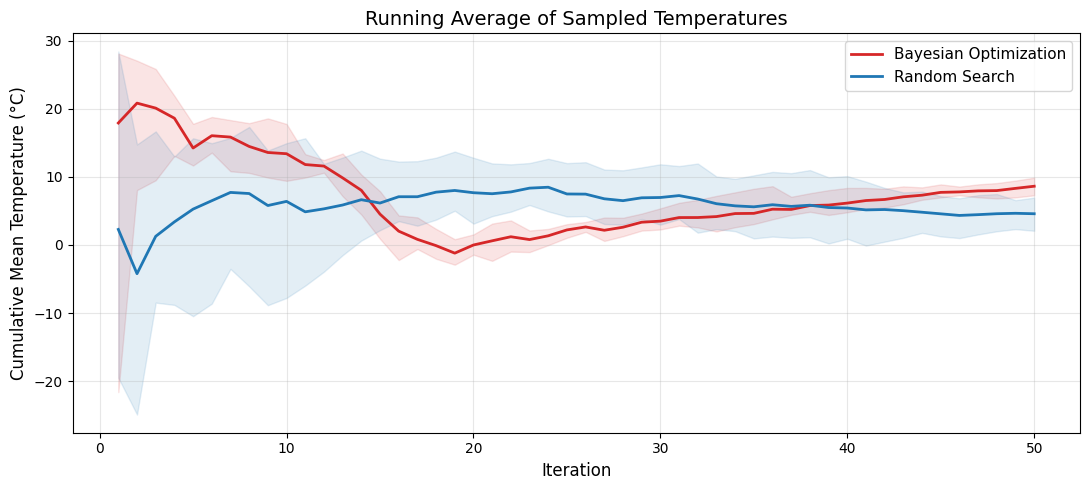

In [25]:
fig, ax = plt.subplots(figsize=(11, 5))

for method, color in COLORS.items():
    sub = df[df["method"] == method]
    pivot = sub.pivot(index="iteration", columns="seed", values="temp")
    cum_mean = pivot.expanding().mean()
    avg = cum_mean.mean(axis=1)
    lo = cum_mean.min(axis=1)
    hi = cum_mean.max(axis=1)
    ax.plot(avg.index, avg.values, label=method, color=color, linewidth=2)
    ax.fill_between(avg.index, lo.values, hi.values, color=color, alpha=0.12)

ax.set_xlabel("Iteration", fontsize=12)
ax.set_ylabel("Cumulative Mean Temperature (°C)", fontsize=12)
ax.set_title("Running Average of Sampled Temperatures", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/cumulative_mean.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 12. Summary: Key Findings

In [26]:
print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)

for m in methods_ordered:
    m_final = final[final["method"] == m]["final_best_temp"]
    m_eff = eff[eff["method"] == m]["found_at_iter"]
    m_temps = df[df["method"] == m]["temp"]
    print(f"\n{m}:")
    print(f"  Final best temp:     {m_final.mean():.1f} +/- {m_final.std():.1f} °C")
    print(f"  Best single run:     {m_final.max():.1f} °C")
    print(f"  Found best at iter:  {m_eff.mean():.0f} (avg)")
    print(f"  Mean sampled temp:   {m_temps.mean():.1f} °C")

bo_mean = final[final["method"] == "Bayesian Optimization"]["final_best_temp"].mean()
rand_mean = final[final["method"] == "Random Search"]["final_best_temp"].mean()

print(f"\n{'=' * 60}")
print(f"BO vs Random:  {bo_mean - rand_mean:+.1f} °C difference in mean")

KEY FINDINGS

Bayesian Optimization:
  Final best temp:     34.6 +/- 2.2 °C
  Best single run:     37.7 °C
  Found best at iter:  17 (avg)
  Mean sampled temp:   8.6 °C

Random Search:
  Final best temp:     30.4 +/- 3.1 °C
  Best single run:     35.7 °C
  Found best at iter:  25 (avg)
  Mean sampled temp:   4.6 °C

BO vs Random:  +4.2 °C difference in mean
